# Zaragoza strategic noise map — data download

**Source:** Mapa Estratégico de Ruido de Zaragoza 2016 (viales urbanos) — road-traffic noise of
the urban streets, SoundPLAN model, published by the Ayuntamiento de Zaragoza
([open data catalog entry 1880](https://www.zaragoza.es/sede/portal/datos-abiertos/servicio/catalogo/1880)).

GeoServer WFS: `https://idezar-sig.zaragoza.es/servicios/geoserver/mapa_del_ruido_2016/wfs` —
isophone **polygons** per period (día 7–19h, tarde 19–23h, noche 23–7h), attribute `DB_HI`
(upper bound of the 5-dB band), CRS **EPSG:25830** (ETRS89 / UTM 30N).

Note: the Phase IV strategic map (2022 data) publishes only PDFs and cartographic TIFFs so far,
so the 2016 round is the machine-readable reference (analogous to Viladecans' 2017 round).

In [1]:
import os
import urllib.request
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## Download the WFS layers (skipped if already present)

In [2]:
WFS = ('https://idezar-sig.zaragoza.es/servicios/geoserver/mapa_del_ruido_2016/wfs'
       '?service=WFS&version=1.1.0&request=GetFeature'
       '&typeName=mapa_del_ruido_2016:mapa_ruido_{layer}_2016&outputFormat=SHAPE-ZIP')

_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
os.makedirs(_layers_dir, exist_ok=True)

for layer in ['dia', 'tarde', 'noche']:
    dest = os.path.join(_layers_dir, f'zgz_ruido_{layer}_2016.zip')
    if os.path.exists(dest):
        print('Already downloaded:', dest)
        continue
    print('Downloading', layer, '...')
    urllib.request.urlretrieve(WFS.format(layer=layer), dest)
    print(f'Saved: {dest} ({os.path.getsize(dest)/1e6:.1f} MB)')

Already downloaded: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Zaragoza\layers\zgz_ruido_dia_2016.zip


Saved: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Zaragoza\layers\zgz_ruido_tarde_2016.zip (8.3 MB)


Saved: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Zaragoza\layers\zgz_ruido_noche_2016.zip (4.9 MB)


## Inspect the layers

In [3]:
iso = {}
for layer in ['dia', 'tarde', 'noche']:
    gdf = gpd.read_file(os.path.join(_layers_dir, f'zgz_ruido_{layer}_2016.zip'))
    iso[layer] = gdf
    print(f'{layer}: {len(gdf)} polygons, CRS: {gdf.crs}')
    print(gdf['DB_HI'].value_counts().sort_index().to_string())
    print()

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


dia: 20413 polygons, CRS: EPSG:25830
DB_HI
50.0    4765
55.0    3865
60.0    3815
65.0    4275
70.0    1670
75.0    1185
80.0     632
85.0     203
90.0       3



tarde: 18005 polygons, CRS: EPSG:25830
DB_HI
50.0    4580
55.0    3779
60.0    2749
65.0    3728
70.0    1506
75.0    1140
80.0     478
85.0      45



noche: 9057 polygons, CRS: EPSG:25830
DB_HI
50.0    3219
55.0    2082
60.0    1579
65.0    1580
70.0     484
75.0     112
80.0       1



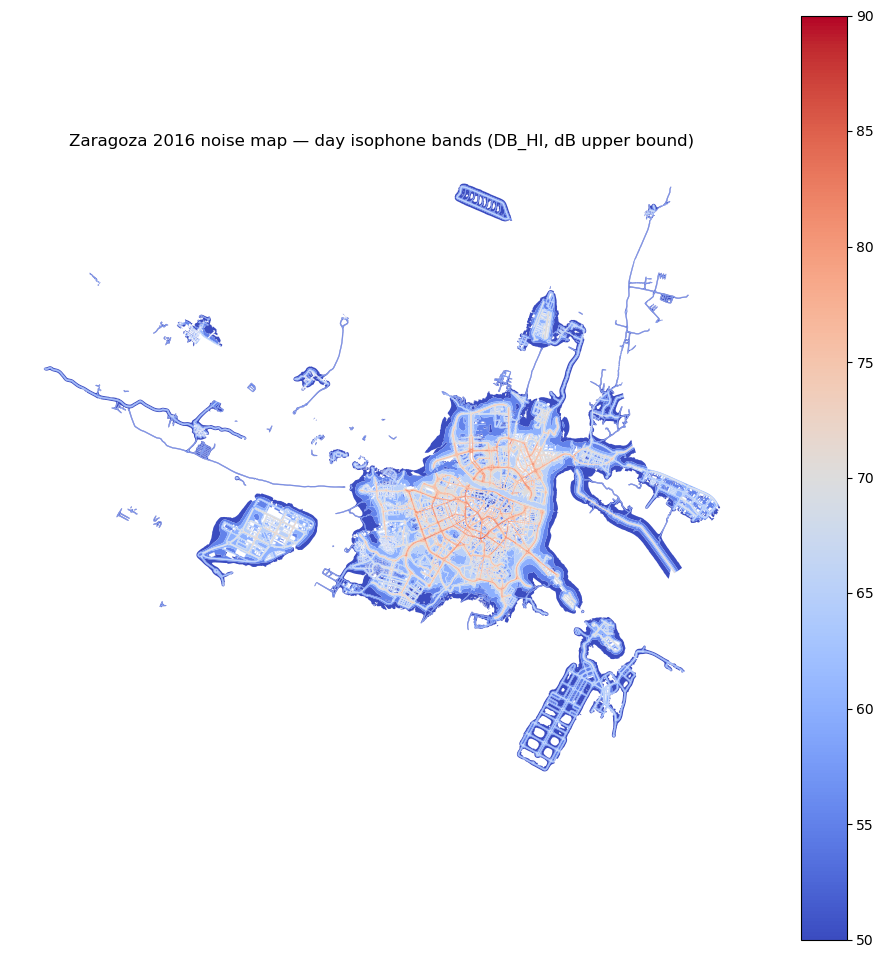

In [4]:
ax = iso['dia'].plot(column='DB_HI', cmap='coolwarm', legend=True, figsize=(12, 12), linewidth=0)
ax.set_title('Zaragoza 2016 noise map — day isophone bands (DB_HI, dB upper bound)')
ax.set_axis_off()

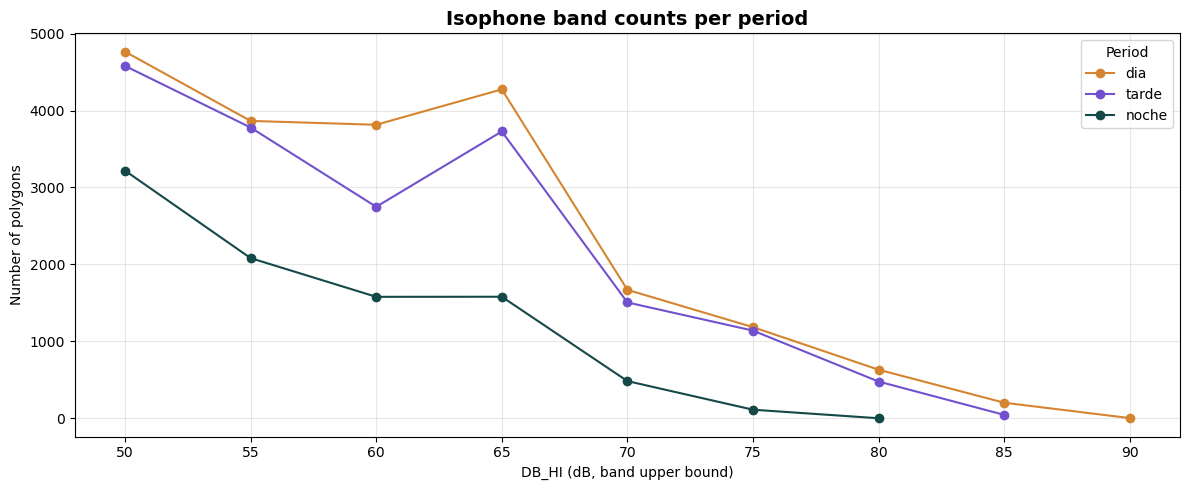

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'dia': '#d58430', 'tarde': '#7251ce', 'noche': '#144849'}
for layer, gdf in iso.items():
    counts = gdf['DB_HI'].value_counts().sort_index()
    ax.plot(counts.index, counts.values, marker='o', label=layer, color=colors[layer])
ax.set_title('Isophone band counts per period', fontsize=14, fontweight='bold')
ax.set_xlabel('DB_HI (dB, band upper bound)')
ax.set_ylabel('Number of polygons')
ax.grid(alpha=0.3)
ax.legend(title='Period')
plt.tight_layout()
plt.show()